In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, chi2_contingency, entropy, pointbiserialr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split.

import warnings
from sklearn.metrics import mean_squared_error

In [2]:


# Загрузка данных
real_data = pd.read_csv('Data/Sber/Clear/transact_1.csv')  # Реальные данные
synth_data = pd.read_csv('Data/Sber/Clear/transact_400000_samples.csv')  # Сгенерированные данные

In [3]:
ONEHOT_FIELDS = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
CATEGORICAL_FIELDS = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
NUMERICAL_FIELDS = ['AMOUNT_EQ', 'EXCHANGE_RATA']

In [ ]:
def analyze_onehot_correlations_simple(real_df, synth_df, onehot_fields, exchange_rate_field=None):
    """
    Простой анализ корреляций между one-hot полями
    """
    print(f"\n{'='*60}")
    print("ONE-HOT FIELD CORRELATION ANALYSIS")
    print(f"{'='*60}")
    
    results = {}
    
    # 1. Кодируем one-hot поля для корреляционного анализа
    available_onehot = [f for f in onehot_fields if f in real_df.columns and f in synth_df.columns]
    
    if not available_onehot:
        print("No one-hot fields available for analysis")
        return results
    
    print(f"Available one-hot fields: {len(available_onehot)}")
    
    # 2. Функция для расчета Cramér's V между двумя категориальными переменными
    def cramers_v(x, y):
        """Calculate Cramér's V statistic for categorial-categorial association"""
        confusion_matrix = pd.crosstab(x, y)
        try:
            chi2 = chi2_contingency(confusion_matrix)[0]
            n = confusion_matrix.sum().sum()
            phi2 = chi2 / n
            r, k = confusion_matrix.shape
            phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
            rcorr = r - ((r-1)**2)/(n-1)
            kcorr = k - ((k-1)**2)/(n-1)
            return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
        except:
            return np.nan
    
    # 3. Создаем матрицы Cramér's V для реальных и синтетических данных
    print("\n1. Cramér's V Correlation Matrices for One-Hot Fields:")
    
    n_fields = len(available_onehot)
    real_cramers_v = np.zeros((n_fields, n_fields))
    synth_cramers_v = np.zeros((n_fields, n_fields))
    
    for i in range(n_fields):
        for j in range(n_fields):
            if i != j:
                real_cramers_v[i, j] = cramers_v(real_df[available_onehot[i]], real_df[available_onehot[j]])
                synth_cramers_v[i, j] = cramers_v(synth_df[available_onehot[i]], synth_df[available_onehot[j]])
    
    # Создаем DataFrames
    real_cramers_v_df = pd.DataFrame(real_cramers_v, 
                                     index=available_onehot, 
                                     columns=available_onehot)
    synth_cramers_v_df = pd.DataFrame(synth_cramers_v, 
                                      index=available_onehot, 
                                      columns=available_onehot)
    
    # Разница между матрицами
    cramers_v_diff = real_cramers_v_df - synth_cramers_v_df
    
    # 4. Визуализация матриц корреляций
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Real data heatmap
    sns.heatmap(real_cramers_v_df, annot=True, fmt='.2f', cmap='YlOrRd', 
                vmin=0, vmax=1, square=True, ax=axes[0], cbar_kws={'label': "Cramér's V"})
    axes[0].set_title('Real Data: Cramér\'s V between One-Hot Fields')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # Synthetic data heatmap
    sns.heatmap(synth_cramers_v_df, annot=True, fmt='.2f', cmap='YlOrRd', 
                vmin=0, vmax=1, square=True, ax=axes[1], cbar_kws={'label': "Cramér's V"})
    axes[1].set_title('Synthetic Data: Cramér\'s V between One-Hot Fields')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
    
    # Difference heatmap
    sns.heatmap(cramers_v_diff, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, square=True, ax=axes[2], cbar_kws={'label': 'Difference (Real - Synthetic)'})
    axes[2].set_title('Difference in Cramér\'s V (Real - Synthetic)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Статистики по различиям
    # Берем только верхний треугольник (без диагонали)
    mask = np.triu(np.ones_like(real_cramers_v_df, dtype=bool), k=1)
    diff_values = cramers_v_diff.values[mask]
    abs_diff_values = np.abs(diff_values)
    
    stats_dict = {
        'mean_absolute_difference': np.nanmean(abs_diff_values),
        'median_absolute_difference': np.nanmedian(abs_diff_values),
        'max_absolute_difference': np.nanmax(abs_diff_values),
        'std_absolute_difference': np.nanstd(abs_diff_values),
        'correlation_preservation_score': max(0, 1 - np.nanmean(abs_diff_values))
    }
    
    print(f"\n2. Correlation Difference Statistics:")
    print(f"   Mean absolute difference: {stats_dict['mean_absolute_difference']:.4f}")
    print(f"   Median absolute difference: {stats_dict['median_absolute_difference']:.4f}")
    print(f"   Max absolute difference: {stats_dict['max_absolute_difference']:.4f}")
    print(f"   Std of differences: {stats_dict['std_absolute_difference']:.4f}")
    print(f"   Correlation preservation score: {stats_dict['correlation_preservation_score']:.3f}")
    
    # 6. Топ-5 пар с наибольшими различиями
    print(f"\n3. Top 5 Pairs with Largest Differences:")
    
    # Создаем список всех пар
    pairs_data = []
    for i in range(n_fields):
        for j in range(i+1, n_fields):  # Только верхний треугольник
            f1, f2 = available_onehot[i], available_onehot[j]
            real_val = real_cramers_v_df.loc[f1, f2]
            synth_val = synth_cramers_v_df.loc[f1, f2]
            diff = real_val - synth_val
            abs_diff = abs(diff)
            
            pairs_data.append({
                'field1': f1,
                'field2': f2,
                'real_cramers_v': real_val,
                'synth_cramers_v': synth_val,
                'difference': diff,
                'abs_difference': abs_diff
            })
    
    # Сортируем по абсолютной разнице
    pairs_df = pd.DataFrame(pairs_data)
    top_pairs = pairs_df.nlargest(5, 'abs_difference')
    
    for idx, row in top_pairs.iterrows():
        print(f"   {row['field1']} vs {row['field2']}:")
        print(f"     Real Cramér's V: {row['real_cramers_v']:.3f}")
        print(f"     Synthetic Cramér's V: {row['synth_cramers_v']:.3f}")
        print(f"     Difference: {row['difference']:.3f}")
    
    


In [ ]:


# # 7. ИНТЕГРИРОВАННЫЙ АНАЛИЗ СВЯЗЕЙ МЕЖДУ ПОЛЯМИ (обновленная версия)
# def test_field_relationships(real_df, synth_df):
#     """
#     Анализ взаимосвязей между полями
#     """
#     results = {}
    
#     print(f"\n{'='*60}")
#     print("FIELD RELATIONSHIPS ANALYSIS")
#     print(f"{'='*60}")
    
#     # 1. Связь MCC и суммы транзакций
#     if 'MCC' in real_df.columns and 'AMOUNT_EQ' in real_df.columns:
#         print("\n1. MCC vs Transaction Amount Analysis:")
        
#         # Группировка по MCC
#         real_mcc_amount = real_df.groupby('MCC')['AMOUNT_EQ'].agg(['mean', 'std', 'count'])
#         synth_mcc_amount = synth_df.groupby('MCC')['AMOUNT_EQ'].agg(['mean', 'std', 'count'])
        
#         # Общие MCC (преобразуем set в list)
#         common_mcc = list(set(real_mcc_amount.index) & set(synth_mcc_amount.index))
        
#         if len(common_mcc) > 0:
#             # Сравнение средних сумм по MCC
#             mean_diffs = []
#             for mcc in common_mcc:
#                 real_mean = real_mcc_amount.loc[mcc, 'mean']
#                 synth_mean = synth_mcc_amount.loc[mcc, 'mean']
#                 if real_mean > 0:
#                     diff_pct = abs(real_mean - synth_mean) / real_mean * 100
#                     mean_diffs.append(diff_pct)
            
#             avg_mean_diff = np.mean(mean_diffs) if mean_diffs else 0
            
#             # Безопасное получение корреляции
#             try:
#                 # Используем только общие MCC
#                 real_means = [real_mcc_amount.loc[mcc, 'mean'] for mcc in common_mcc]
#                 synth_means = [synth_mcc_amount.loc[mcc, 'mean'] for mcc in common_mcc]
                
#                 # Если есть хотя бы 2 точки для корреляции
#                 if len(real_means) > 1 and len(synth_means) > 1:
#                     correlation = np.corrcoef(real_means, synth_means)[0, 1]
#                 else:
#                     correlation = None
#             except:
#                 correlation = None
            
#             results['mcc_amount_relationship'] = {
#                 'common_mcc_count': len(common_mcc),
#                 'avg_mean_diff_pct': avg_mean_diff,
#                 'correlation_real_vs_synth': correlation
#             }
            
#             print(f"  Common MCCs: {len(common_mcc)}")
#             print(f"  Avg amount difference: {avg_mean_diff:.1f}%")
#             if correlation is not None:
#                 print(f"  Correlation of MCC means: {correlation:.3f}")
#             else:
#                 print("  Correlation: Not enough data")
#         else:
#             print("  No common MCCs found")
    

    
#     # 3. Связь типа операции и суммы
#     if 'OpType' in real_df.columns and 'AMOUNT_EQ' in real_df.columns:
#         print("\n3. Operation Type vs Transaction Amount:")
        
#         real_optype_amount = real_df.groupby('OpType')['AMOUNT_EQ'].agg(['mean', 'count'])
#         synth_optype_amount = synth_df.groupby('OpType')['AMOUNT_EQ'].agg(['mean', 'count'])
        
#         # Общие типы операций (преобразуем set в list)
#         common_optypes = list(set(real_optype_amount.index) & set(synth_optype_amount.index))
        
#         if len(common_optypes) > 0:
#             try:
#                 # Сравнение
#                 fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
#                 # Средние суммы
#                 real_means = [real_optype_amount.loc[op, 'mean'] for op in common_optypes]
#                 synth_means = [synth_optype_amount.loc[op, 'mean'] for op in common_optypes]
                
#                 x = np.arange(len(common_optypes))
#                 width = 0.35
                
#                 axes[0].bar(x - width/2, real_means, width, label='Real', alpha=0.7)
#                 axes[0].bar(x + width/2, synth_means, width, label='Synthetic', alpha=0.7)
#                 axes[0].set_xticks(x)
#                 axes[0].set_xticklabels(common_optypes, rotation=45, ha='right')
#                 axes[0].set_ylabel('Average Amount')
#                 axes[0].set_title('Average Amount by Operation Type')
#                 axes[0].legend()
                
#                 # Количества
#                 real_counts = [real_optype_amount.loc[op, 'count'] for op in common_optypes]
#                 synth_counts = [synth_optype_amount.loc[op, 'count'] for op in common_optypes]
                
#                 axes[1].bar(x - width/2, real_counts, width, label='Real', alpha=0.7)
#                 axes[1].bar(x + width/2, synth_counts, width, label='Synthetic', alpha=0.7)
#                 axes[1].set_xticks(x)
#                 axes[1].set_xticklabels(common_optypes, rotation=45, ha='right')
#                 axes[1].set_ylabel('Transaction Count')
#                 axes[1].set_title('Transaction Count by Operation Type')
#                 axes[1].legend()
                
#                 plt.tight_layout()
#                 plt.show()
#             except Exception as e:
#                 print(f"  Visualization error: {e}")
#         else:
#             print("  No common operation types found")
    
#     return results


In [ ]:
def comprehensive_field_analysis(real_data, synth_data):
    """
    Комплексный анализ всех полей
    """
    print("=" * 80)
    print("COMPREHENSIVE FIELD-BY-FIELD ANALYSIS")
    print("=" * 80)
    
    all_results = {}
    
    # Проверка доступности полей
    available_onehot = [f for f in ONEHOT_FIELDS if f in real_data.columns]
    available_categorical = [f for f in CATEGORICAL_FIELDS if f in real_data.columns]
    available_numerical = [f for f in NUMERICAL_FIELDS if f in real_data.columns]
    
    print(f"Available OneHot fields: {len(available_onehot)}/{len(ONEHOT_FIELDS)}")
    print(f"Available Categorical fields: {len(available_categorical)}/{len(CATEGORICAL_FIELDS)}")
    print(f"Available Numerical fields: {len(available_numerical)}/{len(NUMERICAL_FIELDS)}")
    
    # 0. Анализ корреляций с one-hot полями
    print(f"\n{'='*60}")
    print("ONEHOT FIELD CORRELATION ANALYSIS")
    print(f"{'='*60}")
    onehot_corr_results = analyze_onehot_correlations(
        real_data, 
        synth_data, 
        available_onehot,
        available_numerical,
        available_categorical
    )
    all_results['onehot_correlations'] = onehot_corr_results
    
    # 1. Общий анализ корреляций
    print(f"\n{'='*60}")
    print("GENERAL CORRELATION ANALYSIS")
    print(f"{'='*60}")
    correlation_results = compare_correlations(
        real_data, 
        synth_data, 
        numerical_fields=available_numerical,
        categorical_fields=available_categorical,
        onehot_fields=available_onehot
    )
    all_results['general_correlations'] = correlation_results
    
    # 2. OneHot поля
    # if available_onehot:
    #     print(f"\n{'='*60}")
    #     print("ONEHOT FIELDS MARGINAL ANALYSIS")
    #     print(f"{'='*60}")
    #     onehot_results = test_onehot_fields(real_data, synth_data, available_onehot)
    #     all_results['onehot_fields'] = onehot_results
    
    # 3. Категориальные поля с высокой кардинальностью
    # if available_categorical:
    #     print(f"\n{'='*60}")
    #     print("HIGH-CARDINALITY CATEGORICAL FIELDS ANALYSIS")
    #     print(f"{'='*60}")
    #     categorical_results = test_high_cardinality_fields(real_data, synth_data, available_categorical)
    #     all_results['categorical_fields'] = categorical_results
    
    # # 4. Числовые поля
    # if available_numerical:
    #     print(f"\n{'='*60}")
    #     print("NUMERICAL FIELDS ANALYSIS")
    #     print(f"{'='*60}")
    #     numerical_results = test_numerical_fields(real_data, synth_data, available_numerical)
    #     all_results['numerical_fields'] = numerical_results

    # 6. Анализ взаимосвязей
    print(f"\n{'='*60}")
    print("FIELD RELATIONSHIPS ANALYSIS")
    print(f"{'='*60}")
    relationship_results = test_field_relationships(real_data, synth_data)
    all_results['relationships'] = relationship_results
    
    # 7. Сводный отчет
    print(f"\n{'='*80}")
    print("COMPREHENSIVE SUMMARY REPORT")
    print(f"{'='*80}")
    
    summary = {
        'onehot_fields_passed': 0,
        'onehot_fields_total': 0,
        'categorical_fields_passed': 0,
        'categorical_fields_total': 0,
        'numerical_fields_passed': 0,
        'numerical_fields_total': 0,
        'correlation_preservation_score': 0,
        'onehot_correlation_score': 0
    }
    
    # Подсчет результатов для OneHot полей (маргинальные распределения)
    if 'onehot_fields' in all_results:
        for field, results in all_results['onehot_fields'].items():
            summary['onehot_fields_total'] += 1
            if results.get('distribution_similar', False):
                summary['onehot_fields_passed'] += 1
    
    # Подсчет результатов для категориальных полей
    if 'categorical_fields' in all_results:
        summary['categorical_fields_total'] = len(all_results['categorical_fields'])
        # Для категориальных полей считаем прошедшими если меньше 10% пересечения
        for field, results in all_results['categorical_fields'].items():
            if results.get('overlap_percentage', 100) < 10:
                summary['categorical_fields_passed'] += 1
    
    # Подсчет результатов для числовых полей
    if 'numerical_fields' in all_results:
        for field, results in all_results['numerical_fields'].items():
            summary['numerical_fields_total'] += 1
            if results.get('distributions_similar', False):
                summary['numerical_fields_passed'] += 1
    
    # Оценка общих корреляций
    if 'general_correlations' in all_results and 'numerical_correlations' in all_results['general_correlations']:
        summary['correlation_preservation_score'] = all_results['general_correlations']['numerical_correlations'].get('correlation_preservation_score', 0)
    
    # Оценка one-hot корреляций
    if 'onehot_correlations' in all_results and 'summary' in all_results['onehot_correlations']:
        onehot_summary = all_results['onehot_correlations']['summary']
        if onehot_summary:
            quality_scores = [metrics['quality_score'] for metrics in onehot_summary.values()]
            summary['onehot_correlation_score'] = np.mean(quality_scores) if quality_scores else 0
    
    # Вывод сводки
    print("\nQUALITY METRICS SUMMARY:")
    print(f"{'Metric':<40} {'Score':<10} {'Status':<10}")
    print("-" * 60)
    
    # Маргинальные распределения
    for field_type in ['onehot', 'categorical', 'numerical']:
        passed = summary.get(f'{field_type}_fields_passed', 0)
        total = summary.get(f'{field_type}_fields_total', 0)
        score = passed/total*100 if total > 0 else 0
        status = "✓ GOOD" if score > 70 else "⚠ MODERATE" if score > 50 else "✗ POOR"
        print(f"{field_type.capitalize()} Fields Match: {passed}/{total} {score:>5.1f}% {status:>10}")
    
    # Корреляции
    corr_score = summary.get('correlation_preservation_score', 0) * 100
    corr_status = "✓ GOOD" if corr_score > 70 else "⚠ MODERATE" if corr_score > 50 else "✗ POOR"
    print(f"General Correlation Preservation: {'':<15} {corr_score:>5.1f}% {corr_status:>10}")
    
    # One-hot корреляции
    onehot_corr_score = summary.get('onehot_correlation_score', 0) * 100
    onehot_corr_status = "✓ GOOD" if onehot_corr_score > 70 else "⚠ MODERATE" if onehot_corr_score > 50 else "✗ POOR"
    print(f"One-Hot Correlation Preservation: {'':<12} {onehot_corr_score:>5.1f}% {onehot_corr_status:>10}")
    
    # Общий балл (взвешенный)
    weights = {
        'onehot_marginal': 0.15,
        'categorical_marginal': 0.15,
        'numerical_marginal': 0.15,
        'general_correlation': 0.25,
        'onehot_correlation': 0.30
    }
    
    overall_score = (
        weights['onehot_marginal'] * (summary.get('onehot_fields_passed', 0) / max(1, summary.get('onehot_fields_total', 1))) +
        weights['categorical_marginal'] * (summary.get('categorical_fields_passed', 0) / max(1, summary.get('categorical_fields_total', 1))) +
        weights['numerical_marginal'] * (summary.get('numerical_fields_passed', 0) / max(1, summary.get('numerical_fields_total', 1))) +
        weights['general_correlation'] * summary.get('correlation_preservation_score', 0) +
        weights['onehot_correlation'] * summary.get('onehot_correlation_score', 0)
    ) * 100
    
    print(f"\n{'Overall Quality Score':<40} {overall_score:>5.1f}%")
    
    # Рекомендации
    print(f"\n{'='*80}")
    print("DETAILED RECOMMENDATIONS")
    print(f"{'='*80}")
    
    if overall_score > 80:
        print("✓ EXCELLENT: Synthetic data preserves both marginal distributions and all correlation structures.")
        print("  Suitable for production use, advanced analytics, and machine learning tasks.")
    elif overall_score > 65:
        print("✓ GOOD: Synthetic data captures most patterns from real data.")
        print("  Suitable for development, testing, and most analytical purposes.")
    elif overall_score > 50:
        print("⚠ MODERATE: Some discrepancies in distributions or correlations detected.")
        
        # Специфические рекомендации
        recommendations = []
        if summary.get('onehot_fields_passed', 0) / max(1, summary.get('onehot_fields_total', 1)) < 0.7:
            recommendations.append("  - Improve one-hot field marginal distributions")
        if summary.get('onehot_correlation_score', 0) < 0.6:
            recommendations.append("  - Focus on preserving one-hot field correlations")
        if summary.get('correlation_preservation_score', 0) < 0.6:
            recommendations.append("  - Improve general correlation structure")
        
        if recommendations:
            print("  Specific areas for improvement:")
            for rec in recommendations:
                print(rec)
    else:
        print("✗ POOR: Significant differences from real data.")
        print("  Requires model retraining with focus on:")
        
        if summary.get('onehot_correlation_score', 0) < 0.4:
            print("    - One-hot field correlations and associations")
        if summary.get('correlation_preservation_score', 0) < 0.4:
            print("    - General correlation structure")
        if summary.get('onehot_fields_passed', 0) / max(1, summary.get('onehot_fields_total', 1)) < 0.4:
            print("    - One-hot field distributions")
    
    # Детальные рекомендации по one-hot корреляциям
    if 'onehot_correlations' in all_results and 'summary' in all_results['onehot_correlations']:
        onehot_summary = all_results['onehot_correlations']['summary']
        problematic_areas = []
        
        for rel_type, metrics in onehot_summary.items():
            if metrics.get('quality_score', 0) < 0.6:
                problematic_areas.append(rel_type)
        
        if problematic_areas:
            print(f"\n⚠ One-Hot Correlation Issues:")
            print(f"  Problematic areas: {', '.join(problematic_areas)}")
            print("  Consider adjusting model architecture or training to better capture these relationships")
    
    return all_results, summary

In [112]:
def analyze_correlations_main(real_data, synth_data, onehot_fields=None, exchange_rate_field='EXCHANGE_RATA'):
    """
    Главная функция для анализа корреляций
    """
    print("=" * 80)
    print("CORRELATION ANALYSIS FOR ONE-HOT FIELDS")
    print("=" * 80)
    
    # Если onehot_fields не указаны, используем стандартные
    if onehot_fields is None:
        onehot_fields = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                         'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
    
    # Проверяем доступные поля
    available_onehot = [f for f in onehot_fields if f in real_data.columns and f in synth_data.columns]
    print(f"One-hot fields to analyze: {available_onehot}")
    
    # Запускаем анализ
    results = analyze_onehot_correlations_simple(
        real_data, 
        synth_data, 
        available_onehot,
        exchange_rate_field
    )
    

    return results

CORRELATION ANALYSIS FOR ONE-HOT FIELDS
One-hot fields to analyze: ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']

ONE-HOT FIELD CORRELATION ANALYSIS
Available one-hot fields: 12

1. Cramér's V Correlation Matrices for One-Hot Fields:


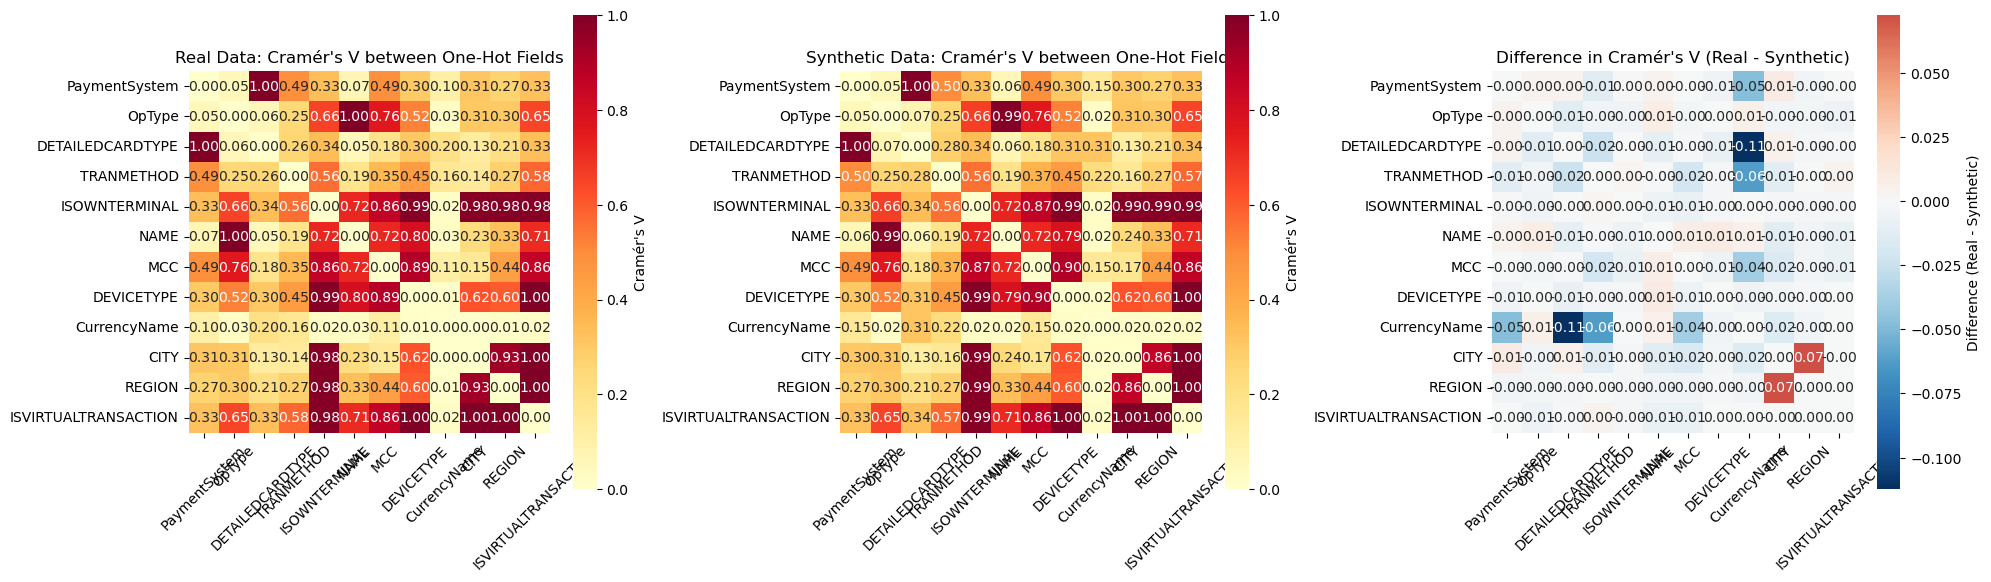


2. Correlation Difference Statistics:
   Mean absolute difference: 0.0100
   Median absolute difference: 0.0046
   Max absolute difference: 0.1123
   Std of differences: 0.0183
   Correlation preservation score: 0.990

3. Top 5 Pairs with Largest Differences:
   DETAILEDCARDTYPE vs CurrencyName:
     Real Cramér's V: 0.201
     Synthetic Cramér's V: 0.314
     Difference: -0.112
   CITY vs REGION:
     Real Cramér's V: 0.933
     Synthetic Cramér's V: 0.860
     Difference: 0.072
   TRANMETHOD vs CurrencyName:
     Real Cramér's V: 0.162
     Synthetic Cramér's V: 0.225
     Difference: -0.062
   PaymentSystem vs CurrencyName:
     Real Cramér's V: 0.103
     Synthetic Cramér's V: 0.150
     Difference: -0.047
   MCC vs CurrencyName:
     Real Cramér's V: 0.110
     Synthetic Cramér's V: 0.148
     Difference: -0.039

CORRELATION MATRIX TABLES

Real Data Correlation Matrix (Cramér's V):
                      PaymentSystem  OpType  DETAILEDCARDTYPE  TRANMETHOD  ISOWNTERMINAL   NAME    

{'real_correlation_matrix':                       PaymentSystem    OpType  DETAILEDCARDTYPE  TRANMETHOD  \
 PaymentSystem              0.000000  0.052273          0.999953    0.488763   
 OpType                     0.052273  0.000000          0.057757    0.249563   
 DETAILEDCARDTYPE           0.999953  0.057757          0.000000    0.255782   
 TRANMETHOD                 0.488763  0.249563          0.255782    0.000000   
 ISOWNTERMINAL              0.332657  0.655375          0.340315    0.560118   
 NAME                       0.066010  0.999989          0.053038    0.187379   
 MCC                        0.488494  0.758412          0.183142    0.352176   
 DEVICETYPE                 0.297391  0.519959          0.303214    0.449652   
 CurrencyName               0.102556  0.026784          0.201343    0.162241   
 CITY                       0.311345  0.308338          0.132260    0.143971   
 REGION                     0.267265  0.299306          0.211427    0.274412   
 ISVIRTUALTRA

In [113]:
analyze_correlations_main(real_data, synth_data, onehot_fields=ONEHOT_FIELDS)

In [114]:
'EXCHANGE_RATA' in synth_data.columns

True

In [ ]:
exchange_rate_field = 'EXCHANGE_RATA'
print(f"\n{'='*60}")
print(f"CORRELATION WITH {exchange_rate_field}")
print(f"{'='*60}")

# Проверяем наличие CurrencyName
if 'CurrencyName' in real_data.columns and 'CurrencyName' in synth_data.columns:
    print(f"\n4. {exchange_rate_field} vs CurrencyName Analysis:")
    
    # Для каждой валюты смотрим распределение курсов
    currencies = real_data['CurrencyName'].unique()
    
    
    
    # Статистики по курсам для каждой валюты
    print(f"\n5. {exchange_rate_field} Statistics by Currency:")
    print(f"{'Currency':<20} {'Real Mean':<12} {'Synth Mean':<12} {'Diff %':<10}")
    print("-" * 60)
    
    currency_stats = []
    for currency in currencies[:10]:  # Топ-10 валют
        real_mean = real_data[real_data['CurrencyName'] == currency][exchange_rate_field].mean()
        synth_mean = synth_data[synth_data['CurrencyName'] == currency][exchange_rate_field].mean()
        
        if pd.notna(real_mean) and pd.notna(synth_mean) and real_mean != 0:
            diff_pct = abs(real_mean - synth_mean) / real_mean * 100
            currency_stats.append({
                'currency': str(currency),
                'real_mean': real_mean,
                'synth_mean': synth_mean,
                'diff_pct': diff_pct
            })
    
    # Сортируем по разнице
    currency_stats.sort(key=lambda x: x['diff_pct'], reverse=True)
    
    for stat in currency_stats[:5]:  # Топ-5 с наибольшими различиями
        print(f"{stat['currency']:<20} {stat['real_mean']:<12.4f} {stat['synth_mean']:<12.4f} {stat['diff_pct']:<10.1f}%")


CORRELATION WITH EXCHANGE_RATA

4. EXCHANGE_RATA vs CurrencyName Analysis:

5. EXCHANGE_RATA Statistics by Currency:
Currency             Real Mean    Synth Mean   Diff %    
------------------------------------------------------------
Евро                 0.0139       0.9997       7082.3    %
Доллар США           0.0168       0.9997       5846.3    %
Рубль                1.0000       0.9997       0.0       %
